In [1]:
import pandas as pd

import json
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

import seaborn as sns
import geopandas as gpd

import folium
from folium.plugins import HeatMap

padding = 10
fontsize = 16
sns.set_theme()
plt.rcParams["figure.figsize"] = (12, 6)  
plt.rcParams["axes.titlepad"] = padding 
plt.rcParams["axes.labelpad"] = padding
plt.rcParams["axes.titlesize"] = fontsize 
plt.rcParams["axes.labelsize"] = fontsize 

In [2]:
def convert_price(x):
    if '$' in x:
        return int(x.replace('$', '')) * 390
    elif '€' in x:
        return int(x.replace('€', '')) * 450
    else:
        return x
    
def remove_outliers_iqr(df, column):
    prev_shape = None
    while prev_shape != df.shape:
        prev_shape = df.shape
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        df = df[(df[column] >= Q1 - 1.5 * IQR) & (df[column] <= Q3 + 1.5 * IQR)]
    df.reset_index(drop=True, inplace=True)
    return df

def embed_map(m, file_name):
    from IPython.display import IFrame
    m.save(file_name)
    return IFrame(file_name, width='100%', height='500px')


In [3]:
#Reading json data from LIST
with open('data_original.json','r', encoding='utf-8') as f:
    json_data = pd.json_normalize(json.loads(f.read()))

#Converting json data into a Dataframe
data = []
for location in json_data['data'][0]:
    for item in location['data']:
        item_data = {
            'id': item.get('id', ''),
            'attributes': item.get('attr', ''),
            'price': item.get('price', ''),
            'Agency': item.get('clabel', ''),
            'lat': location['lat'],
            'lng': location['lng']
        }
        data.append(item_data)

# list to df
df = pd.DataFrame(data)
df.to_csv('data_original.csv', index=False)
df.shape


(3687, 6)

In [4]:
df.head(5)

,id,attributes,price,Agency,lat,lng
0,21104621,"3 սեն., 100 քմ, 7/15 հարկ",$900 ամսական,"<span class=""ge5"">Գործակալություն</span>",40.186186,44.476470
1,22287859,"3 սեն., 80 քմ, 4/15 հարկ","280,000 ֏ ամսական","<span class=""ge5"">Գործակալություն</span>",40.186186,44.476470
2,22363911,"2 սեն., 73 քմ, 15/16 հարկ","170,000 ֏ ամսական",,40.206549,44.465026
3,22647181,"2 սեն., 72 քմ, 13/16 հարկ","330,000 ֏ ամսական",,40.199413,44.476695
4,22610403,"2 սեն., 65 քմ, 6/16 հարկ","280,000 ֏ ամսական","<span class=""ge5"">Գործակալություն</span>",40.199413,44.476695


In [5]:
#DATA CLEANING
df.duplicated().sum()  # Check for duplicates  - no duplicates found
df.isnull().sum()  # Check for null values - no null values found

#converting lat and lng to float
df['lat'] = df['lat'].astype(float)
df['lng'] = df['lng'].astype(float)


#is seller agent or individual
#example (<span class="ge5">Գործակալություն</span>) turns into True, everything else is False
df['Agency'] = df['Agency']=='<span class="ge5">Գործակալություն</span>'

#converting price to dram and keeping it as integer
#example (350,000 ֏ ամսական) -> 350000,   (€500) -> 225000, ($1000) -> 390000
df['price'] = df['price'].str.replace(r'[^0-9$€]', '', regex=True)
df['price'] = df['price'].apply(convert_price)
df['price'] = df['price'].astype(int)

#separate attributes to get more data columns for analysis
#example (3 սեն., 70 քմ, 5/16 հարկ) turns into 3 rooms, 70 area, 5th floor, 16 max floor
df[['rooms', 'area','floor']] = df['attributes'].str.replace(r'[^0-9,/]','', regex=True).str.split(',', expand=True)
df[['floor','max_floor']] = df['floor'].str.split('/', expand=True)
df['rooms'] = df['rooms'].astype(int)
df['area'] = df['area'].astype(int)
df['floor'] = df['floor'].astype(int)
df['max_floor'] = df['max_floor'].astype(int)
df.drop(columns=['attributes'], inplace=True)

df.to_csv('data_clean.csv', index=False)

df.head()

,id,price,Agency,lat,lng,rooms,area,floor,max_floor
0,21104621,351000,True,40.186186,44.476470,3,100,7,15
1,22287859,280000,True,40.186186,44.476470,3,80,4,15
2,22363911,170000,False,40.206549,44.465026,2,73,15,16
3,22647181,330000,False,40.199413,44.476695,2,72,13,16
4,22610403,280000,True,40.199413,44.476695,2,65,6,16


In [6]:
#and important thing it to get rid of outliers
df = remove_outliers_iqr(df, 'price')

#and for rooms - we have 1-2 apartments with 4+ rooms
df = remove_outliers_iqr(df, 'rooms')

#and for area - we have some really big apartments(few are real and few are typos)
df = remove_outliers_iqr(df, 'area')

In [7]:
#lets add new data columns that lets as know wich region the appartement is
#Figure out where is house is - Yerevan canton
import geopandas as gpd

# manually created all the regions as no public available data was found
#redeing the region poligons
polygons = gpd.read_file('Yerevan.geojson')

#reading the apartments address lng lat
points = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy(df.lng, df.lat),
    crs='EPSG:4326'
)

#finding the region name by the apartments lng lat
regions = gpd.sjoin(points, polygons, how='left', predicate='within')
df['region'] = regions['name']


In [8]:
df

,id,price,Agency,lat,lng,rooms,area,floor,max_floor,region
0,21104621,351000,True,40.186186,44.476470,3,100,7,15,Malatia\nSebastia
1,22287859,280000,True,40.186186,44.476470,3,80,4,15,Malatia\nSebastia
2,22363911,170000,False,40.206549,44.465026,2,73,15,16,Ajapnyak
3,22647181,330000,False,40.199413,44.476695,2,72,13,16,Ajapnyak
4,22610403,280000,True,40.199413,44.476695,2,65,6,16,Ajapnyak
...,...,...,...,...,...,...,...,...,...,...
3209,22518062,280000,True,40.177470,44.538705,3,48,3,5,Nork\nMarash
3210,22432339,100000,False,40.092573,44.551982,1,39,1,3,Nubarashen
3211,21557448,110000,False,40.082271,44.544284,3,85,4,5,Nubarashen
3212,22430930,130000,False,40.086411,44.550267,1,30,2,3,Nubarashen


Text(0.5, 1.0, 'Apartments count per region & Avg. Price')

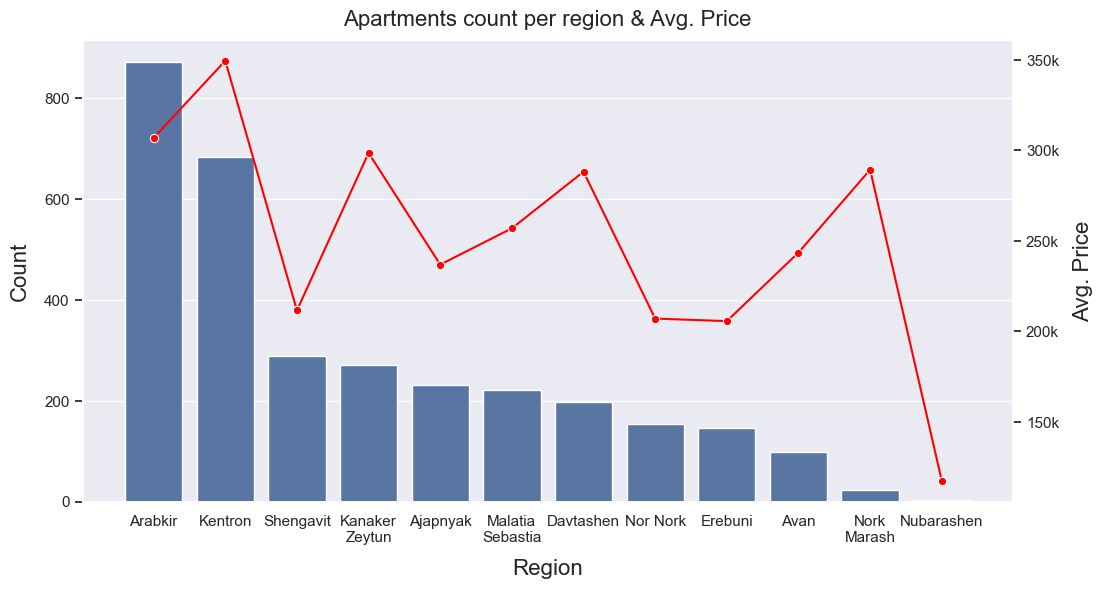

In [9]:
#region distribution
ax= sns.countplot(data=df, x='region', order=df['region'].value_counts().index)
ax1 = ax.twinx()
sns.lineplot(data=df.groupby('region')['price'].mean().reset_index(name='count'), x='region', y='count', color='red', marker='o', ax=ax1)

ax1.grid(False)
ax.set_ylabel("Count")
ax.set_xlabel("Region")
ax1.set_ylabel("Avg. Price")
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))

plt.title('Apartments count per region & Avg. Price')


(array([  0.,  50., 100., 150., 200., 250., 300., 350., 400., 450.]),
 [Text(0, 0.0, '0'),
  Text(0, 50.0, '50'),
  Text(0, 100.0, '100'),
  Text(0, 150.0, '150'),
  Text(0, 200.0, '200'),
  Text(0, 250.0, '250'),
  Text(0, 300.0, '300'),
  Text(0, 350.0, '350'),
  Text(0, 400.0, '400'),
  Text(0, 450.0, '450')])

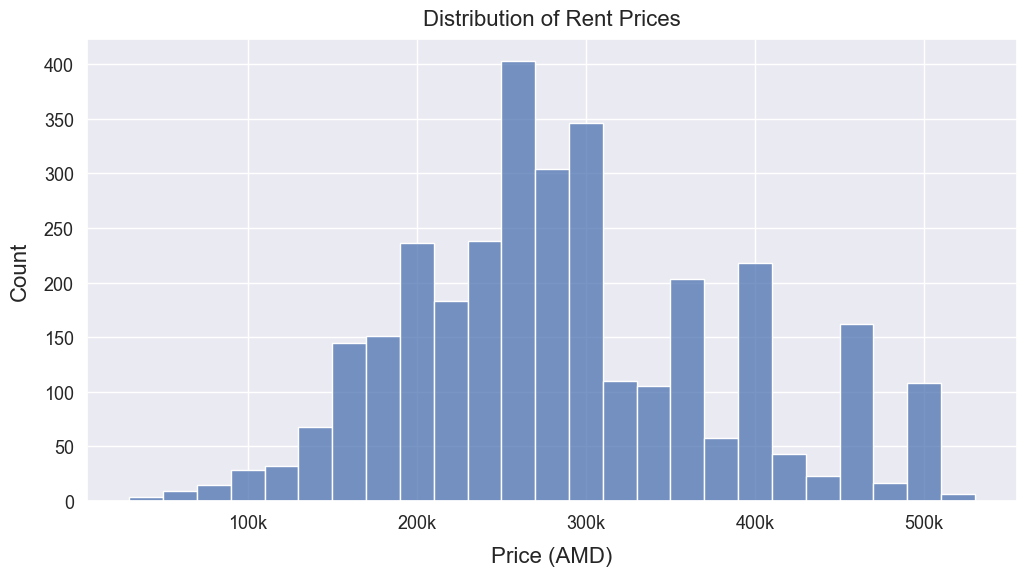

In [10]:
#price distribution
ax = sns.histplot(df['price'], bins=25, common_norm=True)
ax.ticklabel_format(style='plain')

ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))

plt.xlabel('Price (AMD)')
plt.ylabel('Count')
plt.title('Distribution of Rent Prices')
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)


(array([   0.,  200.,  400.,  600.,  800., 1000., 1200., 1400., 1600.,
        1800.]),
 [Text(0, 0.0, '0'),
  Text(0, 200.0, '200'),
  Text(0, 400.0, '400'),
  Text(0, 600.0, '600'),
  Text(0, 800.0, '800'),
  Text(0, 1000.0, '1000'),
  Text(0, 1200.0, '1200'),
  Text(0, 1400.0, '1400'),
  Text(0, 1600.0, '1600'),
  Text(0, 1800.0, '1800')])

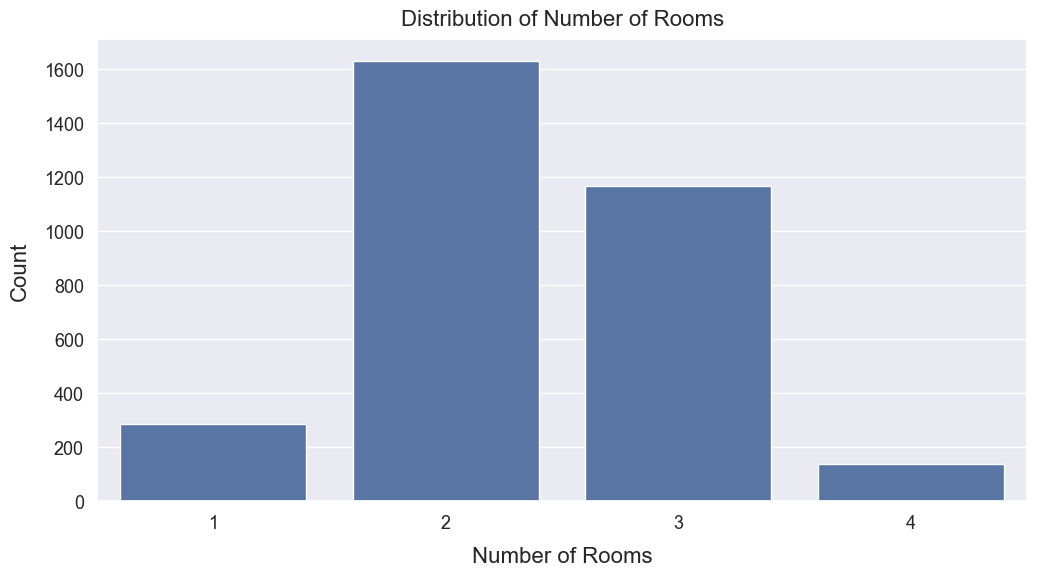

In [11]:
#room count distribution
sns.countplot(data=df, x='rooms')
plt.xlabel('Number of Rooms')
plt.ylabel('Count')
plt.title('Distribution of Number of Rooms')
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)


(array([  0.,  50., 100., 150., 200., 250., 300., 350., 400.]),
 [Text(0, 0.0, '0'),
  Text(0, 50.0, '50'),
  Text(0, 100.0, '100'),
  Text(0, 150.0, '150'),
  Text(0, 200.0, '200'),
  Text(0, 250.0, '250'),
  Text(0, 300.0, '300'),
  Text(0, 350.0, '350'),
  Text(0, 400.0, '400')])

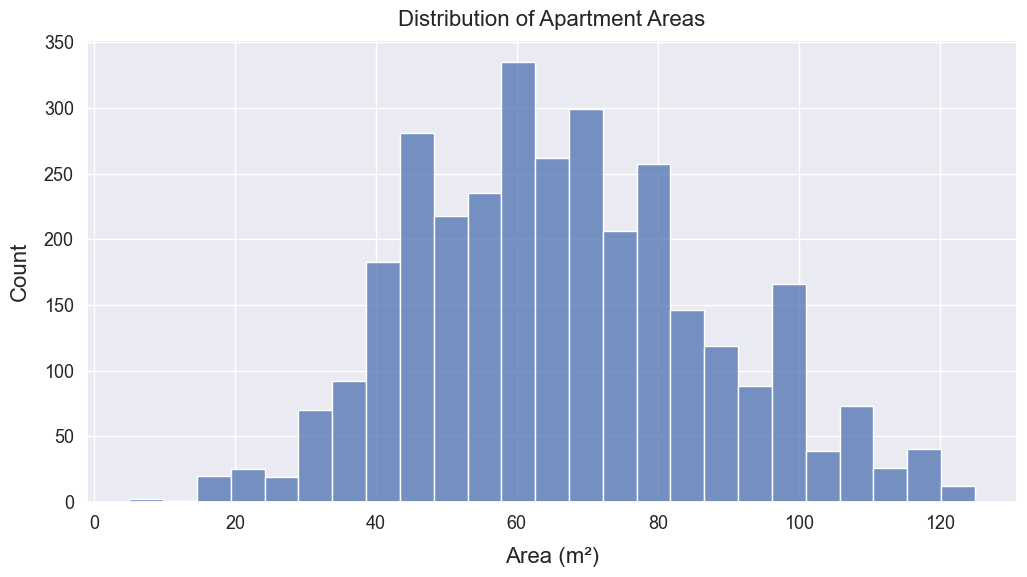

In [12]:
#area distribution
sns.histplot(df['area'], bins=25, common_norm=True)
plt.xlabel('Area (m\u00b2)')
plt.ylabel('Count')
plt.title('Distribution of Apartment Areas')
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)


Text(0.5, 1.0, 'Distribution of Apartment Floors')

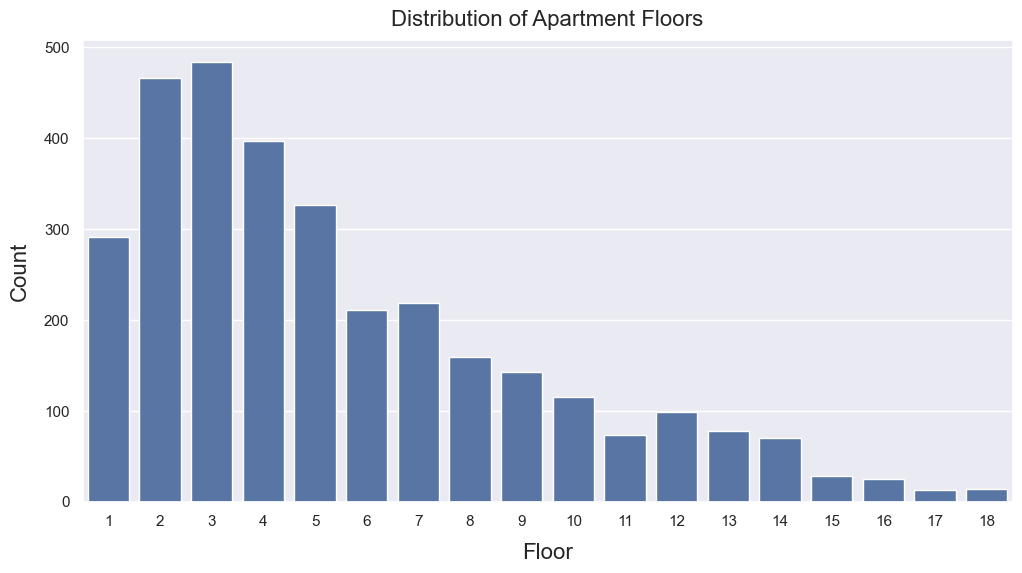

In [13]:
#Floor count distribution
sns.countplot(data=df, x='floor')
plt.xlabel('Floor')
plt.ylabel('Count')
plt.title('Distribution of Apartment Floors')


Text(0.5, 1.0, 'Agent vs Individual')

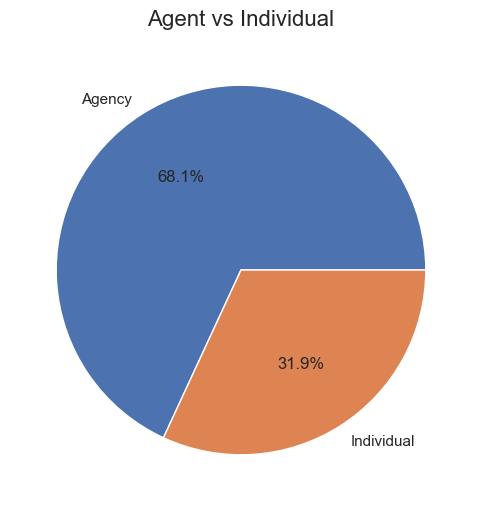

In [14]:
#Floor count distribution
ax = df['Agency'].value_counts().plot(kind='pie', autopct='%1.1f%%', labels=['Agency', 'Individual'])
plt.xlabel('')
plt.ylabel('')
plt.title('Agent vs Individual')


In [15]:
df.head()

,id,price,Agency,lat,lng,rooms,area,floor,max_floor,region
0,21104621,351000,True,40.186186,44.476470,3,100,7,15,Malatia\nSebastia
1,22287859,280000,True,40.186186,44.476470,3,80,4,15,Malatia\nSebastia
2,22363911,170000,False,40.206549,44.465026,2,73,15,16,Ajapnyak
3,22647181,330000,False,40.199413,44.476695,2,72,13,16,Ajapnyak
4,22610403,280000,True,40.199413,44.476695,2,65,6,16,Ajapnyak


<Axes: >

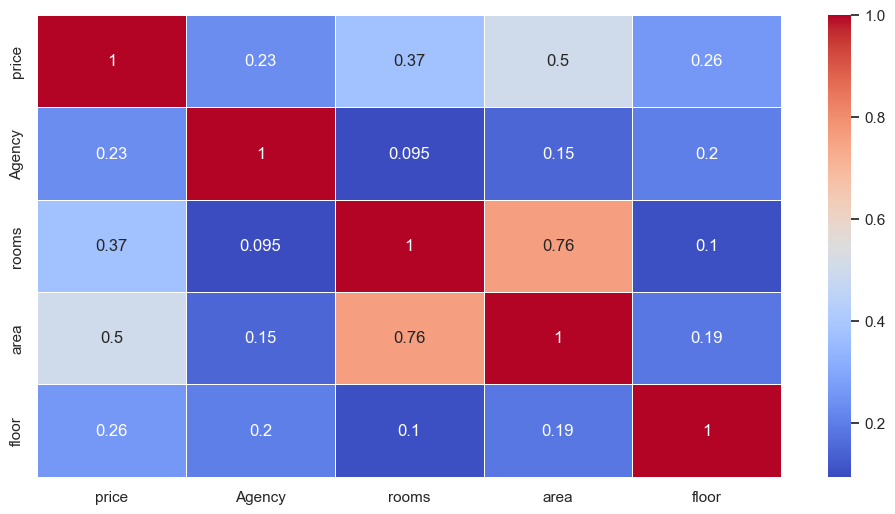

In [16]:
#any correlation? seems no,  only what is expected, price&area 
corr = df[['price','Agency','rooms','area','floor']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5)
#WARNING - LETS FIGURE OUT PRICE AND THE GEOLOCATIONS

Text(0.5, 1.0, 'Distribution of Apartment Floors & Avg. Price')

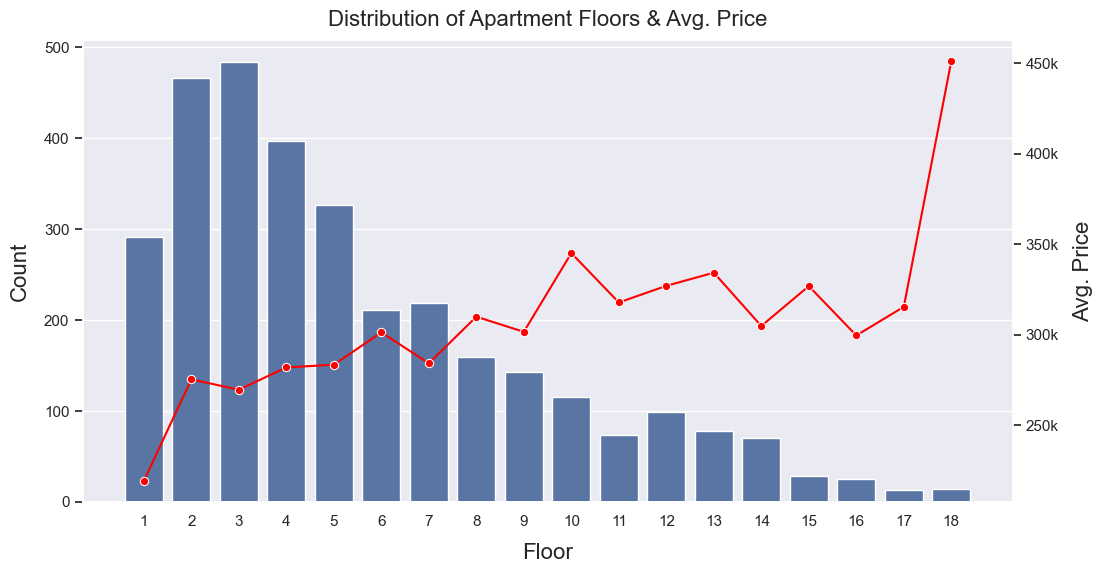

In [17]:
#Floor count distribution
ax= sns.countplot(data=df, x='floor')

ax1 = ax.twinx()
sns.lineplot(data=df.groupby('floor')['price'].mean().reset_index()['price'], color='red',marker='o',ax=ax1)

ax1.grid(False)
ax.set_ylabel("Count")
ax.set_xlabel("Floor")
ax1.set_ylabel("Avg. Price")
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))

plt.xlabel('Floor')
plt.title('Distribution of Apartment Floors & Avg. Price')


In [18]:
#heat of rentable apartments by count
map = folium.Map(location=[40.1624438835815, 44.51679678320299], zoom_start=12.2) 

with open('Metro_line.geojson', 'r') as f:
    geojson_data = json.load(f)
folium.GeoJson(geojson_data, name="Metro Layer", style_function=lambda feature: {'color': 'red'}).add_to(map)
HeatMap(data=df[['lat', 'lng']], radius=15, blur=20, min_opacity=0.3).add_to(map)
map.save("map_house_count.html")
